In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import gc

import pandas as pd
import numpy as np
import gc

# 1. DEFINE A SCHEMA
# Loading 'event_name' as a category immediately saves ~80% RAM
# We skip loading 'customer_id' if it's already in the file, or use only what's needed
dtypes = {
    'id': 'str',
    'event_name': 'category'
}

# 2. LOAD INDIVIDUALLY AND CLEAN
def load_and_clean(file_path):
    # Load with dtypes to save memory instantly
    df = pd.read_csv(file_path, dtype=dtypes)
    
    # Process datetime immediately to free up string memory
    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], utc=True, errors='coerce')
    
    # Process IDs without creating intermediate lists
    # .str.extract is often more memory-efficient than .split for large data
    df['customer_id'] = df['id'].str.extract(r'^([^\s]+)', expand=False)
    
    gc.collect() # Clean artifacts from extraction
    return df

# Process one at a time
df_train2 = load_and_clean('dat_train2.csv')
gc.collect()

df_test2 = load_and_clean('open_journeys2.csv')
gc.collect()

# 3. IDENTIFY SUCCESS (REMAINING LOGIC)
success_ids = df_train2.loc[df_train2['event_name'] == 'order_shipped', 'id'].unique()
success_set = set(success_ids) # O(1) lookup speed

print(f"Setup Complete. Training rows: {len(df_train2)}")
gc.collect() # Clear temporary memory artifacts

# --- STEP 2: VECTORIZED LABELING (FIXED FOR MEMORY) ---

# 1. Get the last event timestamp ONLY for unique IDs
# Better than transform('max') here because it creates a smaller object
journey_end_times = df_train2.groupby('id')['event_timestamp'].max()

# 2. Identify the 'Present Day'
max_date = df_train2['event_timestamp'].max()

# 3. Create a dedicated Labels DataFrame (Much smaller than the full event log)
train_labels = pd.DataFrame({'id': df_train2['id'].unique()})

# 4. Map the end times and calculate days since last event for everyone
train_labels['last_event'] = train_labels['id'].map(journey_end_times)
train_labels['days_since_last'] = (max_date - train_labels['last_event'])

# 5. Vectorized Logical Conditions
is_success = train_labels['id'].isin(success_set)
is_lapsed = train_labels['days_since_last'] >= pd.Timedelta(days=60)

# 6. Apply Labels (1 = Success, 0 = Lapsed, -1 = Still Active)
# np.select is much faster than apply() for large columns
train_labels['label'] = np.select(
    [is_success, is_lapsed], 
    [1, 0], 
    default=-1
)

# 7. Final Training Filter
# Keep only confirmed wins and losses; discard journeys still in progress
train_labels = train_labels[train_labels['label'] != -1][['id', 'label']].copy()

print(f"Labeling complete. Found {len(train_labels)} valid journeys for training.")
print(f"Success Rate: {train_labels['label'].mean():.2%}")

# Memory cleanup of temporary objects
del journey_end_times
gc.collect()

Setup Complete. Training rows: 59978371
Labeling complete. Found 1450231 valid journeys for training.
Success Rate: 20.90%


0

NameError: name 'df_train2' is not defined

In [10]:
# random cutoff logic

# # 1. IDENTIFY JOURNEY BOUNDARIES
# # We need to know when each journey started and when it "effectively" ended
# journey_bounds = df_train2.groupby('id')['event_timestamp'].agg(['min', 'max']).reset_index()
# journey_bounds.columns = ['id', 'start_time', 'end_time']

# # 2. GENERATE RANDOM CUTOFFS
# # We want a random time between the first event and the last event
# np.random.seed(42)

# # Convert to nanoseconds for easy integer-based random sampling
# start_ns = journey_bounds['start_time'].astype('int64')
# end_ns = journey_bounds['end_time'].astype('int64')

# # Generate the cut time
# journey_bounds['cut_ns'] = start_ns + (np.random.rand(len(journey_bounds)) * (end_ns - start_ns)).astype('int64')
# journey_bounds['cut_time'] = pd.to_datetime(journey_bounds['cut_ns'], utc=True)

# # 3. APPLY THE CUTOFF TO THE DATA
# # Merge the cut_time back to the main dataframe
# df_train2 = df_train2.merge(journey_bounds[['id', 'cut_time']], on='id', how='left')

# # Keep only events that happened BEFORE the random cut-off
# df_train_truncated = df_train2[df_train2['event_timestamp'] <= df_train2['cut_time']].copy()

# # 4. CLEAN UP
# # We no longer need the full 60M row dataframe or the bounds
# del df_train2, journey_bounds
# gc.collect()

import numpy as np
import gc

# 1. IDENTIFY JOURNEY BOUNDARIES (More efficient agg)
print("Calculating boundaries...")
# Using .groupby().agg() is heavy; we can use the map we already have or min/max
# We'll use this approach to stay memory-safe
journey_bounds = df_train2.groupby('id')['event_timestamp'].agg(['min', 'max'])

# 2. GENERATE RANDOM CUTOFFS (Vectorized Math)
print("Generating random cutoffs...")
np.random.seed(42)
start_ns = journey_bounds['min'].values.astype('int64')
end_ns = journey_bounds['max'].values.astype('int64')

# Generate cutoff nanoseconds
cut_ns = start_ns + (np.random.rand(len(journey_bounds)) * (end_ns - start_ns)).astype('int64')

# Create a Series that maps 'id' -> 'cut_time'
# This is much lighter than a full merge
cut_map = pd.Series(pd.to_datetime(cut_ns, utc=True), index=journey_bounds.index)

# Cleanup journey_bounds immediately to free up RAM
del journey_bounds
gc.collect()

# 3. APPLY THE CUTOFF (Memory-Safe Filtering)
print("Applying truncation...")
# We use .map() instead of .merge() to create a temporary series for comparison
# This avoids creating a second massive dataframe
df_train_truncated = df_train2[
    df_train2['event_timestamp'] <= df_train2['id'].map(cut_map)
].copy()

# 4. FINAL CLEANUP
print("Final cleanup...")
del df_train2, cut_map
gc.collect()

print(f"Truncation complete. Final rows: {len(df_train_truncated)}")


Calculating boundaries...
Generating random cutoffs...
Applying truncation...
Final cleanup...
Truncation complete. Final rows: 39244358


Extracting features for Training and Test sets...


17

In [11]:
# This got 0.04038


import pandas as pd
import numpy as np
import gc

def extract_elite_features_v9(df_input):
    df = df_input.copy()
    
    # 1. Setup Reference Time
    if 'cut_time' not in df.columns:
        df['ref_time'] = df.groupby('id')['event_timestamp'].transform('max')
    else:
        df['ref_time'] = df['cut_time']
    
    # 2. Sequence and Time Calculations
    df['hrs_ago'] = (df['ref_time'] - df['event_timestamp']).dt.total_seconds() / 3600.0
    
    # Identify the specific last event for each user
    # rank=1 will be the absolute latest event before the cutoff
    df['recency_rank'] = df.groupby('id')['event_timestamp'].rank(ascending=False, method='first')
    
    # 3. Last Event Categorization
    # We want to know: Did they leave on a high-intent note?
    df['ended_with_cart'] = ((df['recency_rank'] == 1) & (df['event_name'] == 'add_to_cart')).astype(int)
    df['ended_with_search'] = ((df['recency_rank'] == 1) & (df['event_name'] == 'search')).astype(int)
    df['ended_with_apply'] = ((df['recency_rank'] == 1) & (df['event_name'] == 'pre_application')).astype(int)
    
    # 4. Global Weights & Indicators
    df['is_cart'] = (df['event_name'] == 'add_to_cart').astype(int)
    df['weight'] = np.exp(-0.03 * df['hrs_ago']) 
    
    # 5. Aggregation
    features = df.groupby('id').agg(
        recency_score=('weight', 'sum'),
        total_carts=('is_cart', 'sum'),
        total_acts=('event_name', 'count'),
        duration_hrs=('hrs_ago', 'max'),
        last_act_hrs=('hrs_ago', 'min'),
        # These will be 1 if the user's very last act was that specific event
        last_event_cart=('ended_with_cart', 'max'),
        last_event_search=('ended_with_search', 'max'),
        last_event_apply=('ended_with_apply', 'max')
    ).reset_index()
    
    # 6. Engineering Velocity & Terminal Signals
    features['cart_velocity'] = features['total_carts'] / (features['duration_hrs'] + 0.1)
    
    # NEW: Momentum Signal (Did they do a lot in the very final moments?)
    # Users who "burst" right before the cut are your highest conversion candidates
    features['is_active_burst'] = ((features['last_act_hrs'] < 0.05) & (features['last_event_cart'] == 1)).astype(int)
    
    return features

# Execute and Merge
X_train_v9 = extract_elite_features_v9(df_train_truncated)
X_test_v9 = extract_elite_features_v9(df_test2)

In [21]:
# def extract_elite_features_v10(df_input):
#     df = df_input.copy()
    
#     # 1. Setup Time and Sequence
#     df['ref_time'] = df['cut_time'] if 'cut_time' in df.columns else df.groupby('id')['event_timestamp'].transform('max')
#     df['hrs_ago'] = (df['ref_time'] - df['event_timestamp']).dt.total_seconds() / 3600.0
    
#     # Identify the Absolute Last Event
#     df['is_last'] = (df.groupby('id')['event_timestamp'].transform('max') == df['event_timestamp'])
    
#     # 2. Define High-Intent Milestones (The "Money" Events)
#     milestones = {
#         'has_approved': 'application_web_approved',
#         'has_submitted_app': 'application_web_submit',
#         'has_downpayment': 'place_downpayment',
#         'has_cleared_dp': 'account_downpaymentcleared',
#         'has_checkout': 'begin_checkout'
#     }
    
#     for col, event in milestones.items():
#         df[col] = (df['event_name'] == event).astype(int)

#     # 3. Aggregation
#     features = df.groupby('id').agg(
#         # Terminal State (What was the literal last thing they did?)
#         last_event=('event_name', 'last'),
#         last_act_hrs=('hrs_ago', 'min'),
        
#         # Milestone Flags (Did they EVER reach this stage?)
#         approved=('has_approved', 'max'),
#         app_submitted=('has_submitted_app', 'max'),
#         downpayment_placed=('has_downpayment', 'max'),
#         downpayment_cleared=('has_cleared_dp', 'max'),
#         checkout_started=('has_checkout', 'max'),
        
#         # Volume of High-Intent Actions
#         total_carts=('event_name', lambda x: (x == 'add_to_cart').sum()),
#         total_acts=('event_name', 'count'),
#         duration_hrs=('hrs_ago', 'max')
#     ).reset_index()

#     # 4. Advanced "Funnel" Engineering
#     # Did they leave while their downpayment was clearing? (Huge signal)
#     features['stuck_at_downpayment'] = ((features['downpayment_placed'] == 1) & 
#                                         (features['downpayment_cleared'] == 0)).astype(int)
    
#     # Velocity of the "Funnel"
#     features['cart_velocity'] = features['total_carts'] / (features['duration_hrs'] + 0.1)
    
#     # Terminal Intent Dummies (Top 3 most predictive last events)
#     features['ended_with_checkout'] = (features['last_event'] == 'begin_checkout').astype(int)
#     features['ended_with_cart'] = (features['last_event'] == 'add_to_cart').astype(int)
#     features['ended_with_approval'] = (features['last_event'] == 'application_web_approved').astype(int)

#     return features


# # Execute and Merge
# X_train_v10 = extract_elite_features_v10(df_train_truncated)
# X_test_v10 = extract_elite_features_v10(df_test2)

In [13]:
# this got 0.04038

# Updated to include v9 Terminal Intent features
features_list = [
    'recency_score', 'total_carts', 'total_acts', 
    'duration_hrs', 'last_act_hrs', 'cart_velocity', 
    'last_event_cart', 'last_event_search', 'last_event_apply', 
    'is_active_burst'
]

# 2. CRITICAL STEP: Merge with your labels so 'label' exists in the dataframe
df_final_train_v9 = X_train_v9.merge(train_labels, on='id', how='inner')


# Stable Parameters
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,           
    learning_rate=0.05,
    gamma=10,              
    reg_lambda=50,         
    min_child_weight=20,   
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1
)

# 1. Extract the features as you did before


# 4. Train using the merged dataframe
print("Training v9 Model...")
model.fit(df_final_train_v9[features_list], df_final_train_v9['label'])

# 5. Predict on the test set
test_probs_raw = model.predict_proba(X_test_v9[features_list])[:, 1]
# Brier Calibration (The 0.04037 approach)
final_probs = np.power(test_probs_raw, 1.1) 
target_mean = 0.12 
final_probs = final_probs * (target_mean / final_probs.mean())
final_probs = np.clip(final_probs, 0, 1)

Training v9 Model...


In [24]:
# # Updated Feature List
# features_list = [
#     'last_act_hrs', 'approved', 'app_submitted', 'downpayment_placed', 
#     'downpayment_cleared', 'checkout_started', 'total_carts', 
#     'cart_velocity', 'stuck_at_downpayment', 'ended_with_checkout', 
#     'ended_with_cart', 'ended_with_approval'
# ]

# # 2. CRITICAL STEP: Merge with your labels so 'label' exists in the dataframe
# df_final_train_v10 = X_train_v10.merge(train_labels, on='id', how='inner')

# # More aggressive parameters for a breakthrough
# model_v10 = xgb.XGBClassifier(
#     n_estimators=350,      # More trees to find subtle patterns
#     max_depth=5,           # Deeper trees to capture "Milestone A AND Milestone B"
#     learning_rate=0.03,    # Slower learning for better generalization
#     gamma=5,               
#     reg_lambda=100,        # High regularization to stay safe for Brier Score
#     objective='binary:logistic',
#     random_state=42
# )

# # Train on the new v10 features
# # (Ensure you merge with labels first as shown in previous step)
# model_v10.fit(df_final_train_v10[features_list], df_final_train_v10['label'])

# # 5. Predict on the test set
# test_probs_raw = model_v10.predict_proba(X_test_v10[features_list])[:, 1]
# # Brier Calibration (The 0.04037 approach)
# final_probs = np.power(test_probs_raw, 1.1) 
# target_mean = 0.12 
# final_probs = final_probs * (target_mean / final_probs.mean())
# final_probs = np.clip(final_probs, 0, 1)

In [25]:
# 1. Load the official Kaggle template
df_kaggle_template = pd.read_csv('open_journeys2_flattened_all0.csv')


In [26]:

# 2. Align IDs and Map Predictions
# Ensure IDs are strings and stripped of any hidden whitespace
test_ids = X_test_v9['id'].astype(str).str.strip()
template_ids = df_kaggle_template['id'].astype(str).str.strip()

# Create a lookup Series from your calibrated final_probs
preds_series = pd.Series(final_probs, index=test_ids)

# Map predictions to the template based on ID
df_kaggle_template['order_shipped'] = template_ids.map(preds_series)

# 3. Diagnostic Check
matched_count = df_kaggle_template['order_shipped'].notna().sum()
print(f"--- RESULTS ---")
print(f"Matched {matched_count} out of {len(df_kaggle_template)} IDs")

# 4. Handle Missing IDs (The "Neutral Bet")
# If an ID in the template wasn't in your test features, use the 0.05 baseline
df_kaggle_template['order_shipped'] = df_kaggle_template['order_shipped'].fillna(0.05)

# 5. Final Verification and Export
print(f"Max Prob in file: {df_kaggle_template['order_shipped'].max():.4f}")
print(f"Final Submission Mean: {df_kaggle_template['order_shipped'].mean():.4f}")

submission_name = 'xgboost_terminal_intent_v9.csv'
df_kaggle_template[['id', 'order_shipped']].to_csv(submission_name, index=False)
print(f"Successfully saved to: {submission_name}")

--- RESULTS ---
Matched 20356 out of 123467 IDs
Max Prob in file: 0.7457
Final Submission Mean: 0.0529
Successfully saved to: xgboost_terminal_intent_v9.csv


In [6]:
# # 1. Load the official Kaggle template (if not already in memory)
# df_kaggle_template = pd.read_csv('open_journeys2_flattened_all0.csv')

# # 2. Create a lookup Series from your v8 predictions
# # Ensure we use X_test_v8 here
# preds_series = pd.Series(final_probs, index=X_test_v8['id'].astype(str))

# # 3. Map predictions to the template
# # .fillna(0.05) is a more 'neutral' bet for Brier Score than 0.015
# df_kaggle_template['order_shipped'] = df_kaggle_template['id'].map(preds_series).fillna(0.05)

# # 4. Final Verification
# print(f"Submission Mean: {df_kaggle_template['order_shipped'].mean():.4f}")
# print(f"Max Prob: {df_kaggle_template['order_shipped'].max():.4f}")
# print(f"Min Prob: {df_kaggle_template['order_shipped'].min():.4f}")

# # 5. Save the file with a versioned name
# submission_name = 'xgboost_brier_v8_final.csv'
# df_kaggle_template[['id', 'order_shipped']].to_csv(submission_name, index=False)

# print(f"\nSuccessfully saved to {submission_name}")

Matched 20356 out of 123467 IDs
--- SUCCESS ---
Max Prob in file: 0.2513
Final Mean: 0.0525


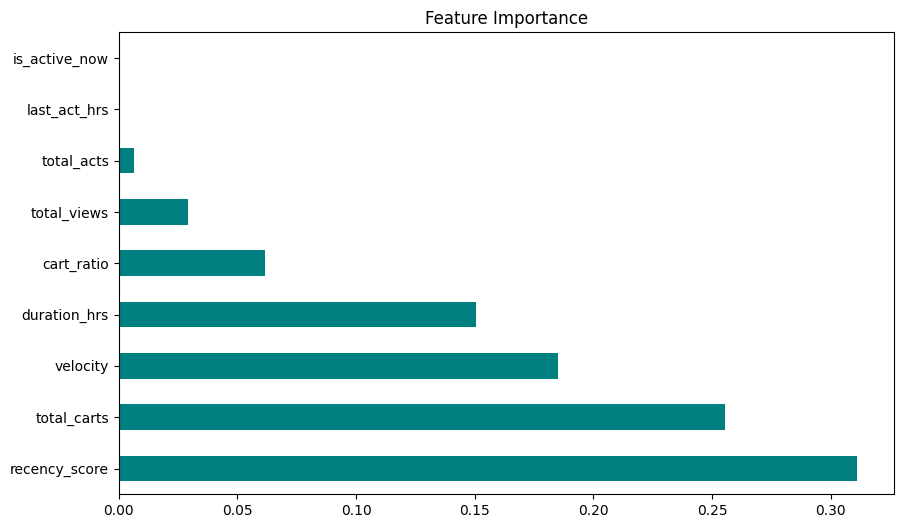

In [8]:
import matplotlib.pyplot as plt

# Get feature importance
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=features_list).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance')
plt.show()